# Imports and data upload

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
data = pd.read_csv('warriorsData.csv')
new = pd.read_csv('warriors_data_new.csv')


In [3]:
average_tickets = data['Num_Tickets_Purchased'].mean()
print(f"The average number of tickets purchased is: {average_tickets:.2f}")

The average number of tickets purchased is: 2.80


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             1000 non-null   object 
 1   customerName           1000 non-null   object 
 2   Age                    1000 non-null   int64  
 3   Fan_Mailing_List       1000 non-null   object 
 4   Customer_Type          1000 non-null   object 
 5   Game_ID                1000 non-null   object 
 6   Num_Tickets_Purchased  1000 non-null   int64  
 7   Seat_Location          1000 non-null   object 
 8   Ticket_Price           1000 non-null   float64
 9   Concession_Purchases   1000 non-null   float64
 10  Days_Before_Game       1000 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 86.1+ KB


In [5]:
data.head()

,customerID,customerName,Age,Fan_Mailing_List,Customer_Type,Game_ID,Num_Tickets_Purchased,Seat_Location,Ticket_Price,Concession_Purchases,Days_Before_Game
0,84d6d15c19b7ef14,"el-Sadek, Lateefa",42,No,Last-Minute,324fd36f67eb,2,Upper,307.64,13.92,2
1,4d570962be6afdbd,"el-Shahan, Wadee'a",61,Yes,In-Between,0c4f632e4414,1,Upper,324.07,18.47,14
2,aaabe0dae9c355d2,"Legge, Megan",27,No,Last-Minute,2f73386a1b02,4,Upper,291.51,3.24,0
3,64f0b74afeb534da,"Burrows, Keenan",32,Yes,Last-Minute,0bdd7a9ec446,2,Upper,184.92,0.00,2
4,e2bef2d7b2a2de4d,"Waggoner, Lucas",34,No,Last-Minute,7040d6183039,1,Upper,198.40,0.00,1


# Exploring data

In [6]:
data['Game_ID'].value_counts()


,count
Game_ID,
5e9c45374431,15
7fc94b0bd340,15
c235c4351211,15
695e4bcb9d6a,13
6302c3d0e2df,13
...,...
cee00fadd776,3
8c6e3539b3f3,3
f651f40d5461,3


In [7]:
data['Fan_Mailing_List'].value_counts()


,count
Fan_Mailing_List,
No,732
Yes,268


In [8]:
categorical_cols = ['Seat_Location', 'Fan_Mailing_List']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    new[col] = le.transform(new[col])
    encoders[col] = le


In [9]:
data.head()

,customerID,customerName,Age,Fan_Mailing_List,Customer_Type,Game_ID,Num_Tickets_Purchased,Seat_Location,Ticket_Price,Concession_Purchases,Days_Before_Game
0,84d6d15c19b7ef14,"el-Sadek, Lateefa",42,0,Last-Minute,324fd36f67eb,2,1,307.64,13.92,2
1,4d570962be6afdbd,"el-Shahan, Wadee'a",61,1,In-Between,0c4f632e4414,1,1,324.07,18.47,14
2,aaabe0dae9c355d2,"Legge, Megan",27,0,Last-Minute,2f73386a1b02,4,1,291.51,3.24,0
3,64f0b74afeb534da,"Burrows, Keenan",32,1,Last-Minute,0bdd7a9ec446,2,1,184.92,0.00,2
4,e2bef2d7b2a2de4d,"Waggoner, Lucas",34,0,Last-Minute,7040d6183039,1,1,198.40,0.00,1


,Age,Fan_Mailing_List,Num_Tickets_Purchased,Seat_Location,Ticket_Price,Concession_Purchases,Days_Before_Game
Age,1.000000,0.290473,0.456243,-0.336031,0.118108,0.434568,0.694620
Fan_Mailing_List,0.290473,1.000000,0.203551,-0.166766,0.065479,0.217651,0.350867
Num_Tickets_Purchased,0.456243,0.203551,1.000000,-0.278729,0.059963,0.375405,0.561011
Seat_Location,-0.336031,-0.166766,-0.278729,1.000000,-0.390369,-0.270560,-0.413121
Ticket_Price,0.118108,0.065479,0.059963,-0.390369,1.000000,0.113896,0.123612
Concession_Purchases,0.434568,0.217651,0.375405,-0.270560,0.113896,1.000000,0.529477
Days_Before_Game,0.694620,0.350867,0.561011,-0.413121,0.123612,0.529477,1.000000


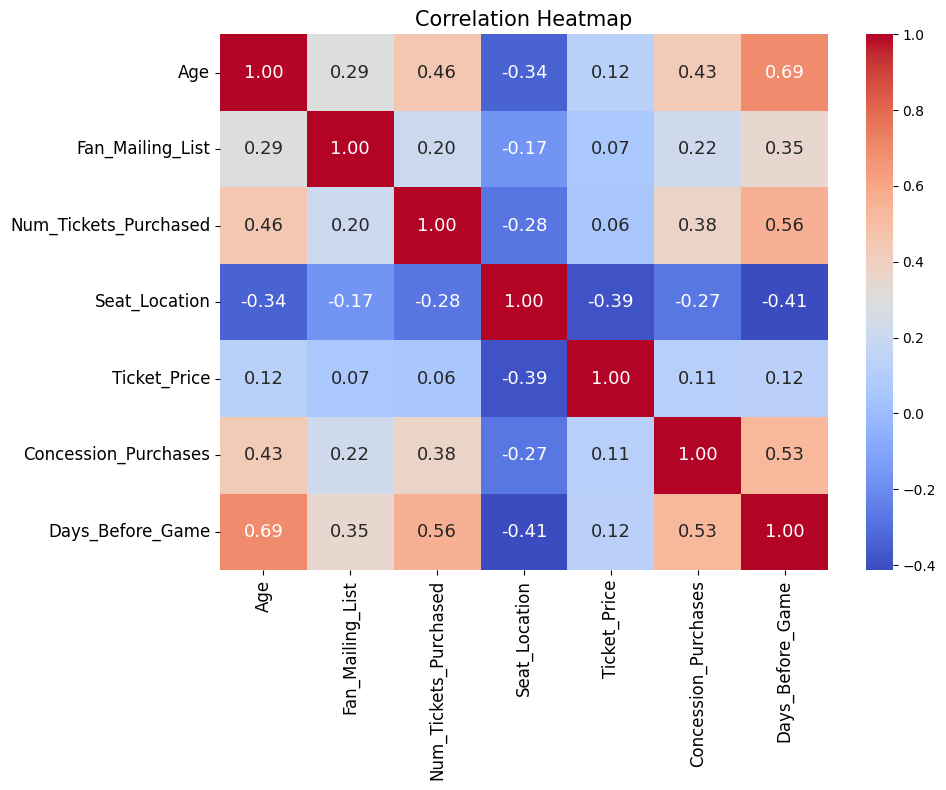

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

numeric_data = data.drop(columns=['customerID',
                                  'customerName',
                                  'Customer_Type',
                                  'Game_ID'])

corr_matrix = numeric_data.corr()
display(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 13}
)
plt.title("Correlation Heatmap", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap.svg", format="svg")
plt.show()



In [11]:
days = data['Days_Before_Game'].value_counts().sort_index()
print("Count for each number of days before game:")
display(days)
print(sum(days))

Count for each number of days before game:


,count
Days_Before_Game,
0,84
1,128
2,79
3,59
4,29
5,20
6,29
7,34
8,36


1000


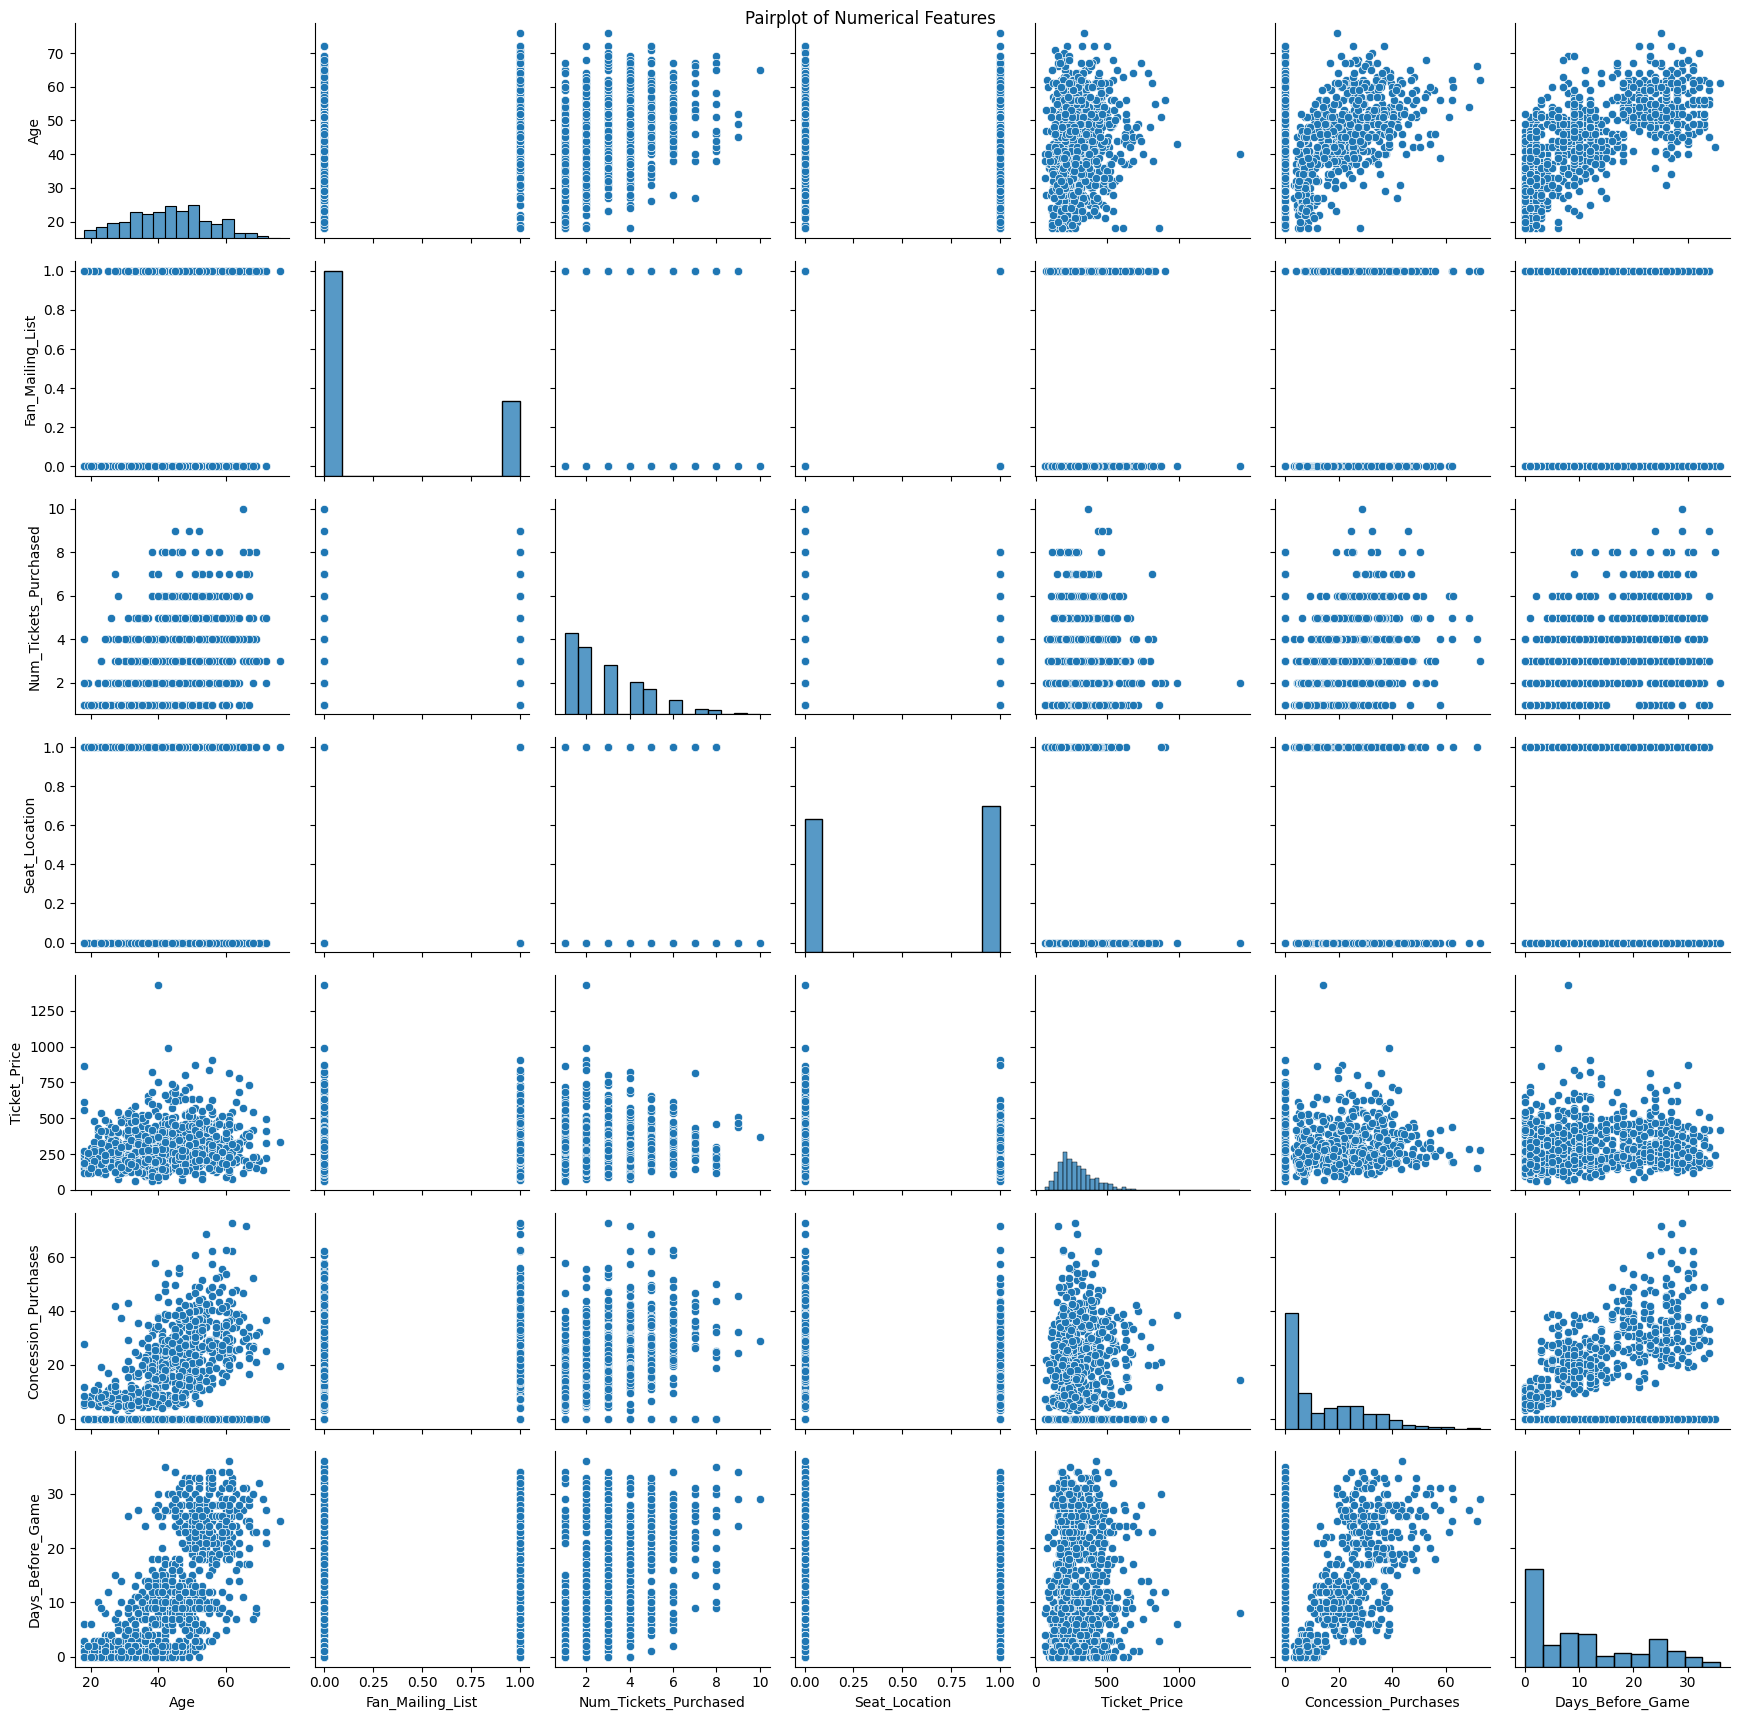

In [12]:
sns.pairplot(data.drop(columns=['customerID', 'customerName', 'Customer_Type', 'Game_ID']))
plt.suptitle("Pairplot of Numerical Features")
plt.tight_layout()
plt.show()

# Classification Models

In [13]:
#drop_cols = ['customerID', 'Customer_Type', 'customerName', 'Game_ID', 'Days_Before_Game']
X = data[['Age', 'Num_Tickets_Purchased', 'Seat_Location','Concession_Purchases']]
y = data['Customer_Type']

X_new = new[['Age', 'Num_Tickets_Purchased', 'Seat_Location','Concession_Purchases']]
y_new = new['Customer_Type']

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_new_scaled = scaler.transform(X_new)

In [15]:
def build_results_df(customer_ids, true_labels, probs, class_labels):
    df = pd.DataFrame({
        'customerID': customer_ids,
        'True_Customer_Type': true_labels
    })
    prob_df = pd.DataFrame(probs, columns=[f"probability-{cls}" for cls in class_labels])
    df = pd.concat([df.reset_index(drop=True), prob_df.reset_index(drop=True)], axis=1)
    df['Predicted_Customer_Type'] = prob_df.idxmax(axis=1).str.replace('probability-', '')
    df.iloc[:, 2:-1] = df.iloc[:, 2:-1].round(2)
    return df

## KNN

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# validation
knn_val_pred = knn.predict(X_val_scaled)
print("KNN Validation Accuracy:", accuracy_score(y_val, knn_val_pred))
print(classification_report(y_val, knn_val_pred))

# predict on new data
knn_probs_new = knn.predict_proba(X_new_scaled)
MLResults_KNN = build_results_df(new['customerID'], y_new, knn_probs_new, knn.classes_)
print("KNN Results on new data:")
display(MLResults_KNN.head())

KNN Validation Accuracy: 0.8133333333333334
              precision    recall  f1-score   support

  In-Between       0.69      0.76      0.73        97
 Last-Minute       0.92      0.90      0.91       112
     Planner       0.83      0.76      0.79        91

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.82      0.81      0.81       300

KNN Results on new data:


,customerID,True_Customer_Type,probability-In-Between,probability-Last-Minute,probability-Planner,Predicted_Customer_Type
0,13a19a2d8c0c6df2,Planner,0.2,0.0,0.8,Planner
1,549329135798fb72,Last-Minute,0.0,1.0,0.0,Last-Minute
2,881b0abac250e536,Last-Minute,0.4,0.6,0.0,Last-Minute
3,1bd5437a8b98bff3,In-Between,0.4,0.4,0.2,In-Between
4,cb41912524b8b601,Planner,0.0,0.0,1.0,Planner


In [17]:
accuracy_knn_new = accuracy_score(y_new, MLResults_KNN['Predicted_Customer_Type'])
print(f"knn Accuracy on new data: {accuracy_knn_new:.3f}")

knn Accuracy on new data: 1.000


## Logistic Regression

In [18]:
logreg = LogisticRegression(max_iter=2000, random_state=0)
logreg.fit(X_train_scaled, y_train)

# validation
logreg_val_pred = logreg.predict(X_val_scaled)
print("Logistic Regression Validation Accuracy:", accuracy_score(y_val, logreg_val_pred))
print(classification_report(y_val, logreg_val_pred))

# predict on new data
logreg_probs_new = logreg.predict_proba(X_new_scaled)
MLResults_LogReg = build_results_df(new['customerID'], y_new, logreg_probs_new, logreg.classes_)
print("Logistic Regression Results on new data:")
display(MLResults_LogReg.head())

Logistic Regression Validation Accuracy: 0.79
              precision    recall  f1-score   support

  In-Between       0.69      0.66      0.67        97
 Last-Minute       0.86      0.90      0.88       112
     Planner       0.81      0.79      0.80        91

    accuracy                           0.79       300
   macro avg       0.78      0.78      0.78       300
weighted avg       0.79      0.79      0.79       300

Logistic Regression Results on new data:


,customerID,True_Customer_Type,probability-In-Between,probability-Last-Minute,probability-Planner,Predicted_Customer_Type
0,13a19a2d8c0c6df2,Planner,0.01,0.00,0.99,Planner
1,549329135798fb72,Last-Minute,0.02,0.98,0.00,Last-Minute
2,881b0abac250e536,Last-Minute,0.23,0.75,0.02,Last-Minute
3,1bd5437a8b98bff3,In-Between,0.62,0.25,0.14,In-Between
4,cb41912524b8b601,Planner,0.35,0.00,0.65,Planner


In [19]:
accuracy_lr_new = accuracy_score(y_new, MLResults_LogReg['Predicted_Customer_Type'])
print(f"lr Accuracy on new data: {accuracy_lr_new:.3f}")

lr Accuracy on new data: 1.000


## Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train_scaled, y_train)

# validation
rf_val_pred = rf.predict(X_val_scaled)
print("Random Forest Validation Accuracy:", accuracy_score(y_val, rf_val_pred))
print(classification_report(y_val, rf_val_pred))

# predict on new data
rf_probs_new = rf.predict_proba(X_new_scaled)
MLResults_RF = build_results_df(new['customerID'], y_new, rf_probs_new, rf.classes_)
print("Random Forest Results on new data:")
display(MLResults_RF.head())


Random Forest Validation Accuracy: 0.82
              precision    recall  f1-score   support

  In-Between       0.71      0.76      0.74        97
 Last-Minute       0.91      0.92      0.92       112
     Planner       0.83      0.76      0.79        91

    accuracy                           0.82       300
   macro avg       0.82      0.81      0.81       300
weighted avg       0.82      0.82      0.82       300

Random Forest Results on new data:


,customerID,True_Customer_Type,probability-In-Between,probability-Last-Minute,probability-Planner,Predicted_Customer_Type
0,13a19a2d8c0c6df2,Planner,0.00,0.00,1.00,Planner
1,549329135798fb72,Last-Minute,0.00,1.00,0.00,Last-Minute
2,881b0abac250e536,Last-Minute,0.24,0.76,0.00,Last-Minute
3,1bd5437a8b98bff3,In-Between,0.72,0.21,0.07,In-Between
4,cb41912524b8b601,Planner,0.18,0.00,0.82,Planner


In [21]:
accuracy_rf_new = accuracy_score(y_new, MLResults_RF['Predicted_Customer_Type'])
print(f"Random Forest Accuracy on new data: {accuracy_rf_new:.3f}")

Random Forest Accuracy on new data: 1.000


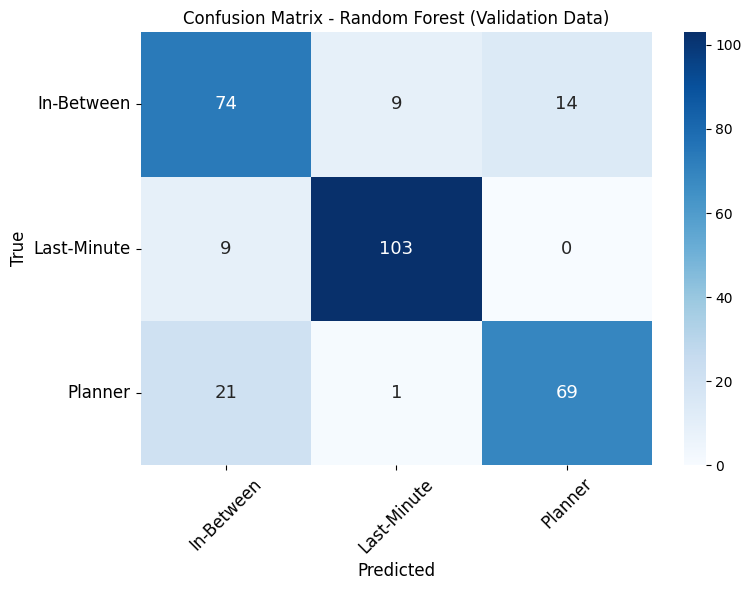

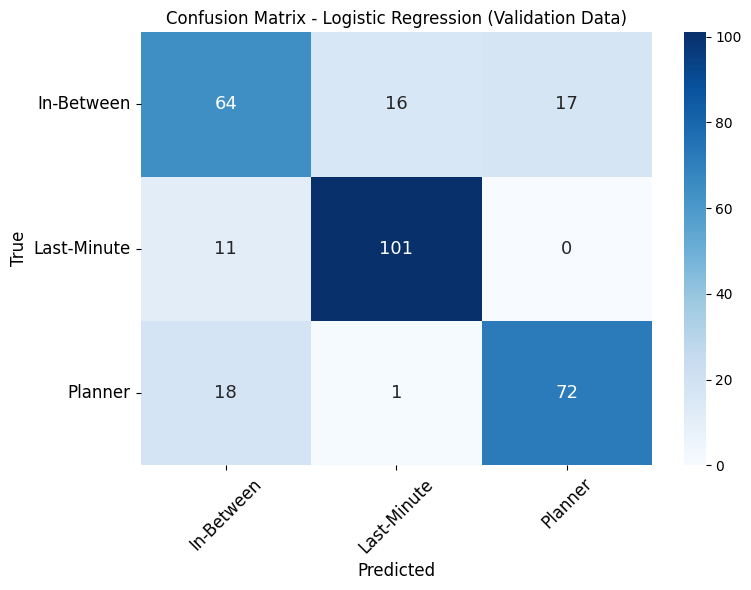

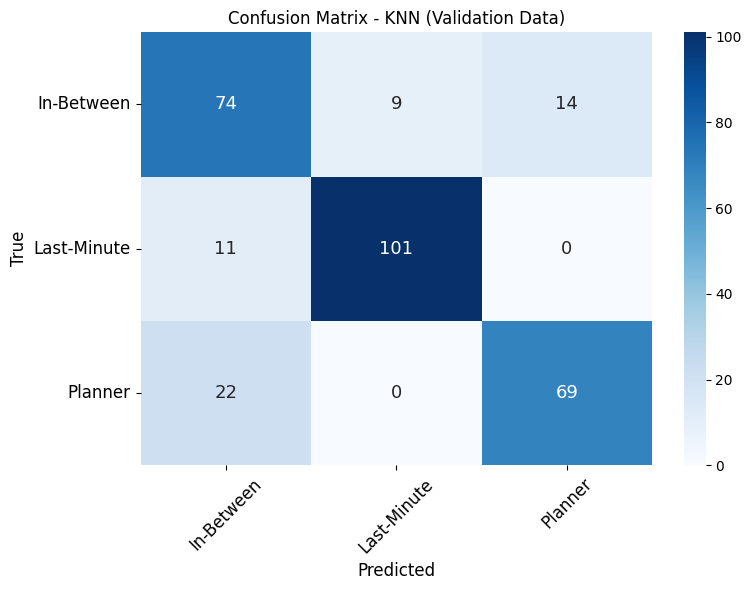

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_val, rf_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=rf.classes_, yticklabels=rf.classes_, annot_kws={"size": 13})
plt.title('Confusion Matrix - Random Forest (Validation Data)')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.savefig("rf_val.svg")
plt.show()

# Confusion Matrix for Logistic Regression
cm_logreg = confusion_matrix(y_val, logreg_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', xticklabels=logreg.classes_, yticklabels=logreg.classes_, annot_kws={"size": 13})
plt.title('Confusion Matrix - Logistic Regression (Validation Data)')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.savefig("lr_val.svg")
plt.show()


# Confusion Matrix for Logistic Regression
cm_knn = confusion_matrix(y_val, knn_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_, annot_kws={"size": 13})
plt.title('Confusion Matrix - KNN (Validation Data)')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.savefig("knn_val.svg")
plt.show()

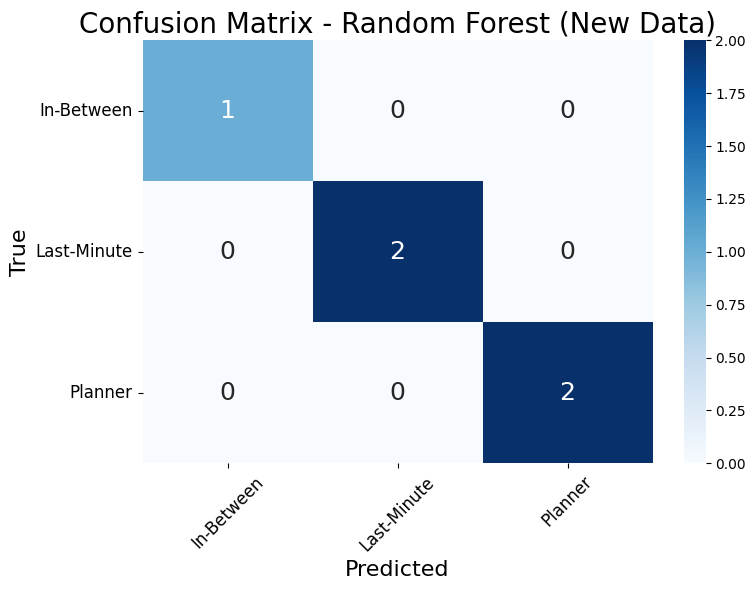

In [23]:
from sklearn.metrics import confusion_matrix

rf_pred_new = rf.classes_[rf_probs_new.argmax(axis=1)]

cm_rf = confusion_matrix(y_new, rf_pred_new)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_, annot_kws={"size": 18})
plt.title('Confusion Matrix - Random Forest (New Data)', fontsize = 20)
plt.xlabel('Predicted', fontsize =16)
plt.ylabel('True', fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.savefig("rf_new_confusion_matrix.svg")
plt.show()


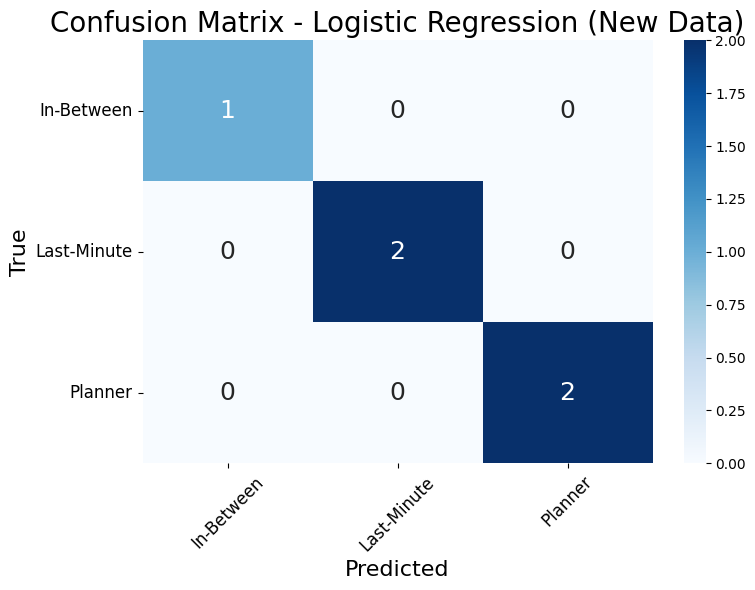

In [24]:


logreg_pred_new = logreg.classes_[logreg_probs_new.argmax(axis=1)]

cm_logreg = confusion_matrix(y_new, logreg_pred_new)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=logreg.classes_, yticklabels=logreg.classes_, annot_kws={"size": 18})
plt.title('Confusion Matrix - Logistic Regression (New Data)', fontsize=20)
plt.xlabel('Predicted', fontsize=16)
plt.ylabel('True', fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.savefig("lr_new_confusion_matrix.svg")
plt.show()


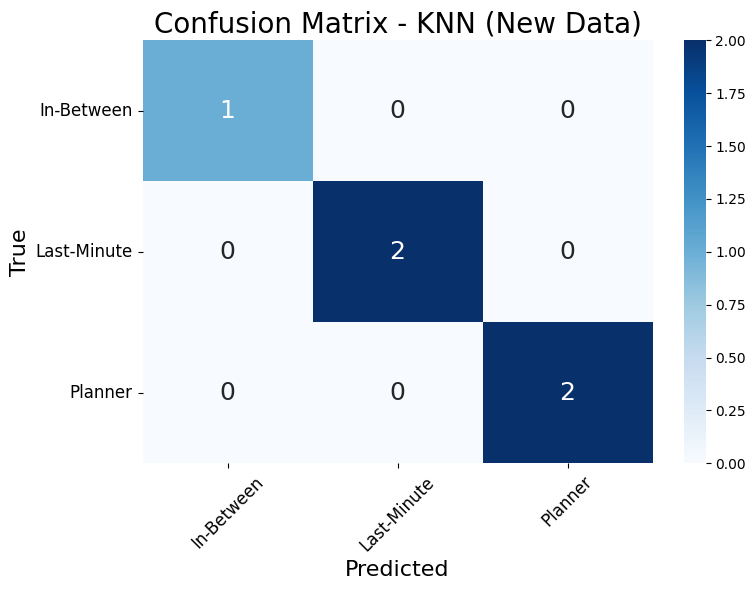

In [25]:
from sklearn.metrics import confusion_matrix

knn_pred_new = knn.classes_[knn_probs_new.argmax(axis=1)]

cm_knn = confusion_matrix(y_new, knn_pred_new)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_, annot_kws={"size": 18})
plt.title('Confusion Matrix - KNN (New Data)', fontsize = 20)
plt.xlabel('Predicted', fontsize =16)
plt.ylabel('True', fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.savefig("knn_new_confusion_matrix.svg")
plt.show()


## Plotting all together probabilities

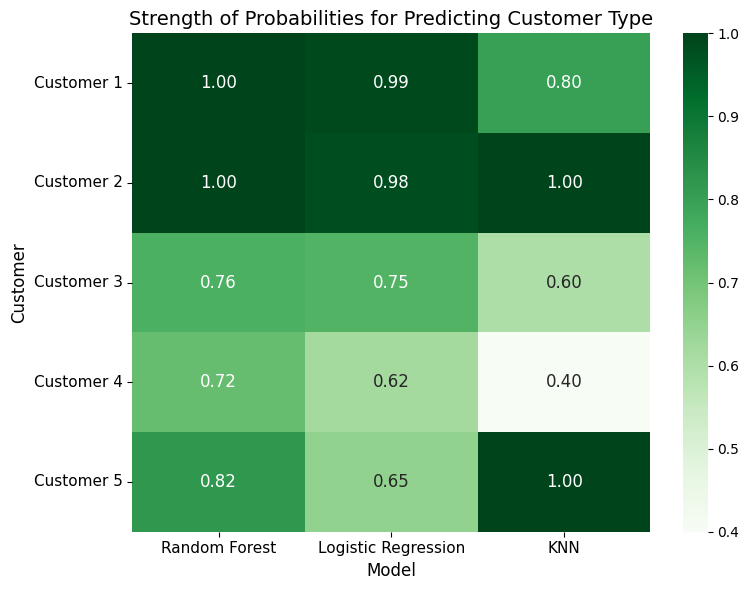

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_models = {
    "Random Forest": [1.0, 1.0, 0.76, 0.72, 0.82],
    "Logistic Regression": [0.99, 0.98, 0.75, 0.62, 0.65],
    "KNN": [0.8, 1.0, 0.6, 0.4, 1.0]
}
index = ["Customer 1", "Customer 2", "Customer 3", "Customer 4", "Customer 5"]

df = pd.DataFrame(data_models, index=index)

plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap="Greens", fmt=".2f", annot_kws={"size": 12})
plt.title("Strength of Probabilities for Predicting Customer Type", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Customer", fontsize=12)
plt.xticks(fontsize=11, rotation=0)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.savefig("probabilities.svg")
plt.show()


# Predicting specific number of days.

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
data.head()

,customerID,customerName,Age,Fan_Mailing_List,Customer_Type,Game_ID,Num_Tickets_Purchased,Seat_Location,Ticket_Price,Concession_Purchases,Days_Before_Game
0,84d6d15c19b7ef14,"el-Sadek, Lateefa",42,0,Last-Minute,324fd36f67eb,2,1,307.64,13.92,2
1,4d570962be6afdbd,"el-Shahan, Wadee'a",61,1,In-Between,0c4f632e4414,1,1,324.07,18.47,14
2,aaabe0dae9c355d2,"Legge, Megan",27,0,Last-Minute,2f73386a1b02,4,1,291.51,3.24,0
3,64f0b74afeb534da,"Burrows, Keenan",32,1,Last-Minute,0bdd7a9ec446,2,1,184.92,0.00,2
4,e2bef2d7b2a2de4d,"Waggoner, Lucas",34,0,Last-Minute,7040d6183039,1,1,198.40,0.00,1


In [29]:
#drop_cols = ['customerID', 'Customer_Type', 'customerName', 'Game_ID', 'Days_Before_Game']
X = data[['Age', 'Concession_Purchases', 'Ticket_Price', 'Fan_Mailing_List', 'Num_Tickets_Purchased', 'Seat_Location' ]]
y = data['Days_Before_Game']

X_new = new[['Age', 'Concession_Purchases', 'Ticket_Price', 'Fan_Mailing_List', 'Num_Tickets_Purchased', 'Seat_Location']]
y_new = new['Days_Before_Game']

In [30]:

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_new_scaled = scaler.transform(X_new)


In [31]:
rf_reg = RandomForestRegressor(random_state=0)
rf_reg.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=0)

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 1, 2, 5, 10],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None] }

grid_search = GridSearchCV(
    rf_reg,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R^2:", grid_search.best_score_)


Fitting 3 folds for each of 300 candidates, totalling 900 fits
Best parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 400}
Best CV R^2: 0.6839545896444092


In [33]:
best_rf = grid_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)

y_val_pred = best_rf.predict(X_val_scaled)
y_new_pred = best_rf.predict(X_new_scaled)


In [34]:
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)
print(f"Validation MSE: {mse_val:.2f}")
print(f"Validation R^2: {r2_val:.2f}")

mse_new = mean_squared_error(y_new, y_new_pred)
r2_new = r2_score(y_new, y_new_pred)
print(f"New Data MSE: {mse_new:.4f}")
print(f"New Data R^2: {r2_new:.4f}")


Validation MSE: 39.82
Validation R^2: 0.61
New Data MSE: 11.1764
New Data R^2: 0.9009


In [35]:
print("Given Multi linreg MSE: ")
print((((28 - 26.934405)**2) + ((1 - 1.852607)**2) + ((3 - 8.943206)**2) + ((7 - 12.686459)**2)+ ((21 - 15.4525)**2)) / 5)

print("Given simple linreg MSE: ")
print((((28 - 16.304673)**2) + ((1 - 5.016153)**2) + ((3 - 15.116408)**2) + ((7 - 13.928142)**2)+ ((21 - 13.928142)**2)) / 5)


Given Multi linreg MSE: 
20.058940233518193
Given simple linreg MSE: 
79.545565704626


In [36]:
results = pd.DataFrame({
    'customerID': new['customerID'],
    'True_Days_Before_Game': y_new,
    'Predicted_Days_Before_Game': y_new_pred.round(1)
})

display(results.head())


,customerID,True_Days_Before_Game,Predicted_Days_Before_Game
0,13a19a2d8c0c6df2,28,22.0
1,549329135798fb72,1,2.3
2,881b0abac250e536,3,6.4
3,1bd5437a8b98bff3,7,9.4
4,cb41912524b8b601,21,21.2


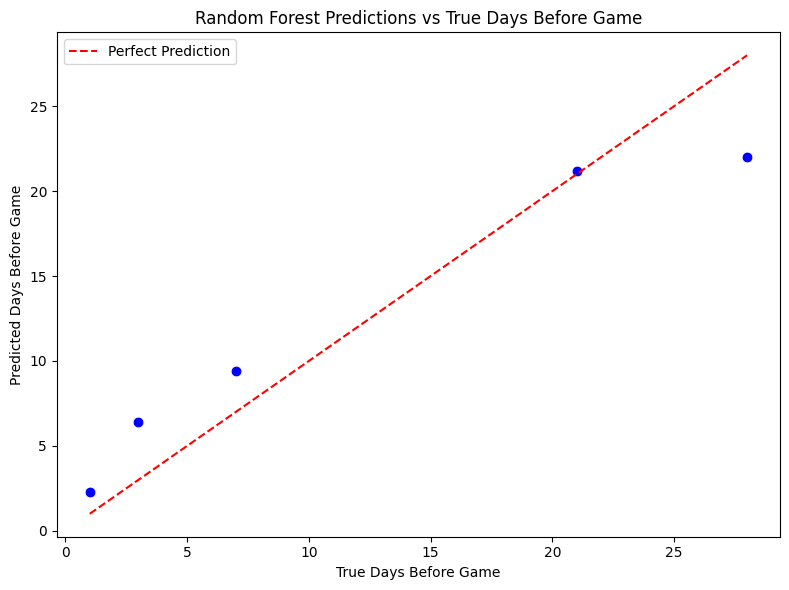

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of True vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='True_Days_Before_Game',
    y='Predicted_Days_Before_Game',
    data=results,
    s=60,
    color='blue'
)

# Plot perfect prediction line
plt.plot([results['True_Days_Before_Game'].min(), results['True_Days_Before_Game'].max()],
         [results['True_Days_Before_Game'].min(), results['True_Days_Before_Game'].max()],
         color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('True Days Before Game')
plt.ylabel('Predicted Days Before Game')
plt.title('Random Forest Predictions vs True Days Before Game')
plt.legend()
plt.tight_layout()
plt.show()


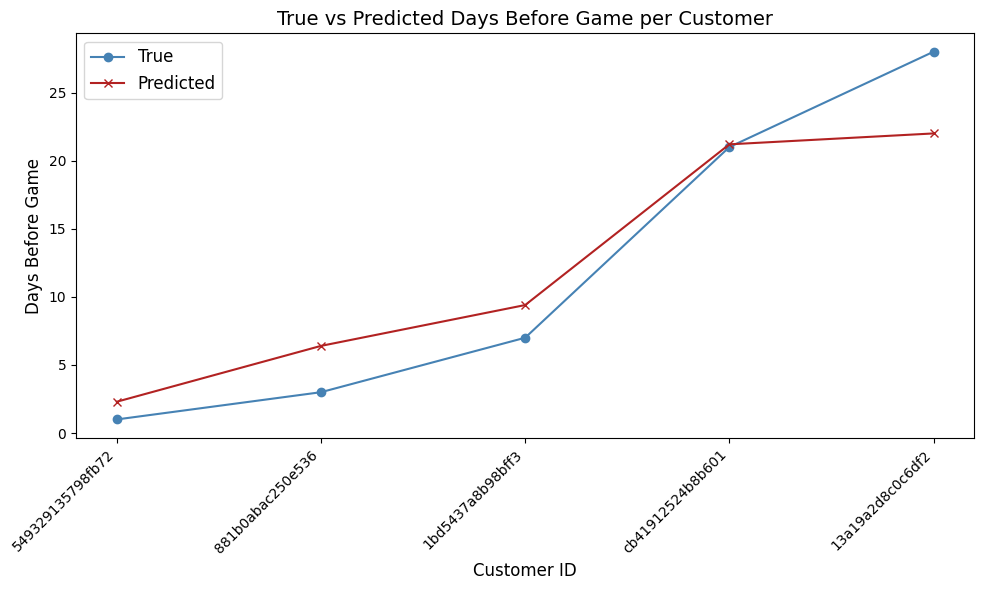

In [38]:
plt.figure(figsize=(10, 6))

# Sort by True_Days_Before_Game for better visualization
results_sorted = results.sort_values('True_Days_Before_Game').reset_index(drop=True)

plt.plot(results_sorted.index, results_sorted['True_Days_Before_Game'], marker='o', label='True', color='SteelBlue')
plt.plot(results_sorted.index, results_sorted['Predicted_Days_Before_Game'], marker='x', label='Predicted', color='FireBrick')

plt.xticks(results_sorted.index, results_sorted['customerID'], rotation=45, ha='right')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Days Before Game', fontsize=12)
plt.title('True vs Predicted Days Before Game per Customer', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("rf_scatter.svg")
plt.show()
